# Background

*The task is to predict which passangers survived the 1912 Titanic shipwreck given passanger information such as Age, Sex, Class etc.*

# Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Data

In [2]:
# Read the data
X_train_full = pd.read_csv('../input/titanic/train.csv', index_col='PassengerId')
X_test_full = pd.read_csv('../input/titanic/test.csv', index_col='PassengerId')

# Number of rows and columns
print(X_train_full.shape)
print(X_test_full.shape)

# First 5 entries
X_train_full.head()

(891, 11)
(418, 10)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Check for missing values**

In [3]:
# Count null values
print(X_train_full.isnull().sum())
print('')
print(X_test_full.isnull().sum())

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

Pclass        0
Name          0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket        0
Fare          1
Cabin       327
Embarked      0
dtype: int64


**Labels and features**

In [4]:
# Labels
y = X_train_full.Survived

# Features
X_train_full.drop(['Survived'], axis=1, inplace=True)

# Feature engineering

**Title feature**

In [5]:
# Extract titles from 'Name' column
X_train_full['Title']=0
X_train_full['Title']=X_train_full.Name.str.extract('([A-Za-z]+)\.')

# Cross tabulation
pd.crosstab(X_train_full.Title,X_train_full.Sex).T

Title,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [6]:
# Raplace rare titles by 'Rare'
X_train_full['Title'].replace(['Capt','Col','Countess','Don','Dr','Jonkheer','Lady','Major',
                           'Master','Miss','Mlle','Mme','Mr','Mrs','Ms','Rev','Sir'],
                           ['Rare','Rare','Rare','Rare','Rare','Rare','Rare',
                            'Rare','Master','Miss','Rare','Rare','Mr','Mrs','Rare',
                            'Rare','Rare'],inplace=True)

# Median age in each group
X_train_full.groupby('Title')['Age'].median()

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      44.5
Name: Age, dtype: float64

<AxesSubplot:xlabel='Title', ylabel='count'>

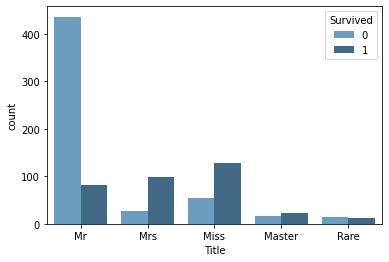

In [7]:
# Countplot
sns.countplot(x="Title",
                   hue="Survived", 
                   data=pd.concat([X_train_full,y],axis=1),
                   palette = 'Blues_d')

In [8]:
# Assign missing age values to be median within each group
X_train_full.loc[(X_train_full.Age.isnull())&(X_train_full.Title=='Master'),'Age']=3.5
X_train_full.loc[(X_train_full.Age.isnull())&(X_train_full.Title=='Miss'),'Age']=21
X_train_full.loc[(X_train_full.Age.isnull())&(X_train_full.Title=='Mr'),'Age']=30
X_train_full.loc[(X_train_full.Age.isnull())&(X_train_full.Title=='Mrs'),'Age']=34.5
X_train_full.loc[(X_train_full.Age.isnull())&(X_train_full.Title=='Rare'),'Age']=44.5

# Check there are not missing values
X_train_full.Age.isnull().sum()

0

**Repeat for test data**

In [9]:
# Repeat feature engineering for test data
X_test_full['Title']=0
X_test_full['Title']=X_test_full.Name.str.extract('([A-Za-z]+)\.') # extract titles

# Raplace rare titles by 'Rare'
X_test_full['Title'].replace(['Capt','Col','Countess','Don','Dr','Jonkheer','Lady','Major',
                           'Master','Miss','Mlle','Mme','Mr','Mrs','Ms','Rev','Sir','Dona'],
                           ['Rare','Rare','Rare','Rare','Rare','Rare','Rare',
                            'Rare','Master','Miss','Rare','Rare','Mr','Mrs','Rare',
                            'Rare','Rare','Rare'],inplace=True)

# Assign missing age values to be median within each group
X_test_full.loc[(X_test_full.Age.isnull())&(X_test_full.Title=='Master'),'Age']=3.5
X_test_full.loc[(X_test_full.Age.isnull())&(X_test_full.Title=='Miss'),'Age']=21
X_test_full.loc[(X_test_full.Age.isnull())&(X_test_full.Title=='Mr'),'Age']=30
X_test_full.loc[(X_test_full.Age.isnull())&(X_test_full.Title=='Mrs'),'Age']=34.5
X_test_full.loc[(X_test_full.Age.isnull())&(X_test_full.Title=='Rare'),'Age']=44.5

# Check there are not missing values
X_test_full.Age.isnull().sum()

0

**HasCabin feature**

In [10]:
# Identify passangers with a recorded Cabin
X_train_full['HasCabin']=X_train_full['Cabin'].notnull()

# Repeat for test data
X_test_full['HasCabin']=X_test_full['Cabin'].notnull()

<AxesSubplot:xlabel='HasCabin', ylabel='count'>

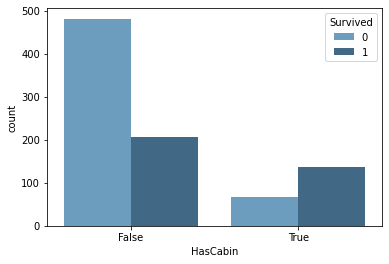

In [11]:
# Countplot
sns.countplot(x="HasCabin",
                   hue="Survived", 
                   data=pd.concat([X_train_full,y],axis=1),
                   palette = 'Blues_d')

# Feature selection

In [12]:
# Select categorical columns to include in model
categorical_cols = ['Pclass', 'Sex', 'Embarked', 'HasCabin'] # Including 'Title' makes model worse

# Select numerical columns to include in model
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# Keep selected columns only
my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_test = X_test_full[my_cols].copy()

# Preprocessing data

In [13]:
# Preprocessing for numerical data
numerical_transformer = SimpleImputer(strategy='median')

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Data preprocessing pipeline
my_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Transform the data
X_train = my_pipeline.fit_transform(X_train)

# Grid Search

In [14]:
# Parameters grid
grid = {'n_estimators': [100, 125, 150, 175, 200, 225, 250], 
        'max_depth': [4, 6, 8, 10, 12]}

# Random Forest Classifier
clf=RandomForestClassifier(random_state=0)

# Grid Search with 4-fold cross validation
grid_model = GridSearchCV(clf,grid,cv=4)

# Train classifier with optimal parameters
grid_model.fit(X_train,y)

GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, 10, 12],
                         'n_estimators': [100, 125, 150, 175, 200, 225, 250]})

**Results from Grid Search**

In [15]:
print("\n The best parameters across ALL searched params:\n",grid_model.best_params_)
print("\n The best score across ALL searched params:\n",grid_model.best_score_)


 The best parameters across ALL searched params:
 {'max_depth': 8, 'n_estimators': 175}

 The best score across ALL searched params:
 0.8238041853512705


# Predictions

In [16]:
# Preprocess test data and fit model
X_test_preprocessed=my_pipeline.transform(X_test)
preds_test = grid_model.predict(X_test_preprocessed)

# Save predictions to file
output = pd.DataFrame({'PassengerId': X_test.index,
                       'Survived': preds_test})

# Check format
output.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [17]:
output.to_csv('submission.csv', index=False)